In [1]:
from __future__ import annotations
import pandas as pd
from pathlib import Path
import copy

from collections import defaultdict
from typing import Any, Dict, Iterable, List, Optional, Union
import math
import matplotlib.pyplot as plt
import numpy as np

#switch dir and load packages
import os

os.chdir(r'..\..')

from app.dike_components.dike_model import DikeModel
from app.cost_calculator import CostCalculator, DirectCostGroundWork, StructureCosts, InfrastructureCosts
from app.unit_costs_and_surcharges import load_kosten_catalogus
from dev.incremental_costs.utils import get_dimensions_dict_from_df, modified_cost_computation, make_reinforcement_incremental, compute_incremental_volumes, compute_incremental_costs


Dit notebook geeft een voorbeeld hoe kosten kunnen worden bepaald uit output files van de Verkenning-2.0-backend
We gebruiken 3 kosteninschattingen van de Scheldestromen casus als voorbeeld.

## Invoerpaden en incrementele versterkingen
In onderstaande cel moet de werkmap met de kostenuitvoer worden geselecteerd, en de filenamen van de verschillende versterkingen. Daarbij kan per file een naam van de maatregel worden opgegeven waarmee later evt. kan worden gecombineerd tot adaptatiepad.

In [2]:
# Path of WJK
working_dir = Path(r"c:\Users\klerk_wj\Stichting Deltares\KIA – Aanpasbaar en Uitbreidbaar - Documents\WP3 casestudies\2c WIP casus WSSS\designs toolbox KOSWAT")
# Path of Yida
# working_dir = Path(r"C:\Users\tao\OneDrive - Stichting Deltares\KIA – Aanpasbaar en Uitbreidbaar - Documents\WP3 casestudies\2c WIP casus WSSS\designs toolbox KOSWAT")

## SETTINGS ## 
files = ['ontwerpvariant grond gestacked/kostenoverzicht design grond 1.xlsx',
         'ontwerpvariant grond gestacked/kostenoverzicht grond 2 aanlegprofiel.xlsx',
         'ontwerpvariant grond gestacked/kostenoverzicht grond 3 aanlegprofiel.xlsx',]

names = ["Grondversterking 2025", "Grondversterking 2075", "Grondversterking 2125"]

alternatives = dict(zip(names, files))


## Berekenen van kosten van incrementele versterkingen
Nu gaan we de kosten van incrementele versterkingen bepalen. Deze worden gebaseerd op de met de toolbox bepaalde kosten. 
We hebben dus kosten van bijv huidige situatie naar Grondversterking 2026 en huidige situatie naar Grondversterking 2075.
We gaan nu de kosten berekenen voor Grondversterking 2025 naar Grondversterking 2075, dus alleen de meerkosten.

In [3]:
dike = DikeModel(complexity = 'gemiddelde maatregel')

#load costs for all alternatives
cost_dataframes_per_alternative = {}
for name, file in alternatives.items():
    cost_dataframes_per_alternative[name] = pd.read_excel(working_dir / file, sheet_name='Kosten')

#dimensions for all alternatives
dimensions = {}
for name, df in cost_dataframes_per_alternative.items():
    dimensions[name] = get_dimensions_dict_from_df(df)

#recomputation of plain costs for all alternatives
cost_summaries = {}
full_cost_dicts = {}
for name, dimension in dimensions.items():
    cost_summaries[name], full_cost_dicts[name] = modified_cost_computation(dike, dimension)
    print(f"Kosten van beginsituatie naar {name}:")
    print(f"€{cost_summaries[name]['Kosten excl. BTW'].sum():,.0f}")
    print("\n")

df_all_costs = pd.concat(cost_summaries.values(), axis=1)
df_all_costs.columns = cost_summaries.keys()
print("Kosten van alle losse alternatieven:")
df_all_costs.sum()

Kosten van beginsituatie naar Grondversterking 2025:
€1,279,338


Kosten van beginsituatie naar Grondversterking 2075:
€1,587,444


Kosten van beginsituatie naar Grondversterking 2125:
€2,074,299


Kosten van alle losse alternatieven:


Grondversterking 2025    1.279338e+06
Grondversterking 2075    1.587444e+06
Grondversterking 2125    2.074299e+06
dtype: float64

In [4]:
cost_per_increment_summary, cost_per_increment_detailed = compute_incremental_costs(names, dimensions, dike)

df_all_increments = pd.concat(cost_per_increment_summary.values(), axis=1)
df_all_increments.columns = cost_per_increment_summary.keys()
print("Kosten van alle incrementele stappen:")
df_all_increments.sum()

Kosten van Grondversterking 2025:
€1,279,338


Incrementele kosten van Grondversterking 2025 naar Grondversterking 2075:
€1,360,823


Incrementele kosten van Grondversterking 2075 naar Grondversterking 2125:
€1,727,025


Kosten van alle incrementele stappen:


Grondversterking 2025                             1.279338e+06
Grondversterking 2025 to Grondversterking 2075    1.360823e+06
Grondversterking 2075 to Grondversterking 2125    1.727025e+06
dtype: float64

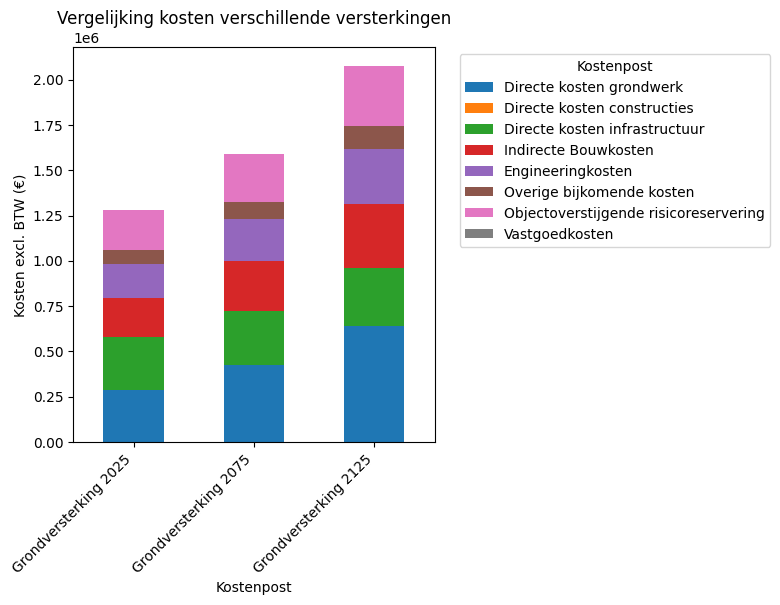

In [7]:
ax = df_all_costs.T.plot(kind="bar", figsize=(8, 6), stacked=True)

plt.title("Vergelijking kosten verschillende versterkingen")
plt.ylabel("Kosten excl. BTW (€)")
plt.xlabel("Kostenpost")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Kostenpost", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


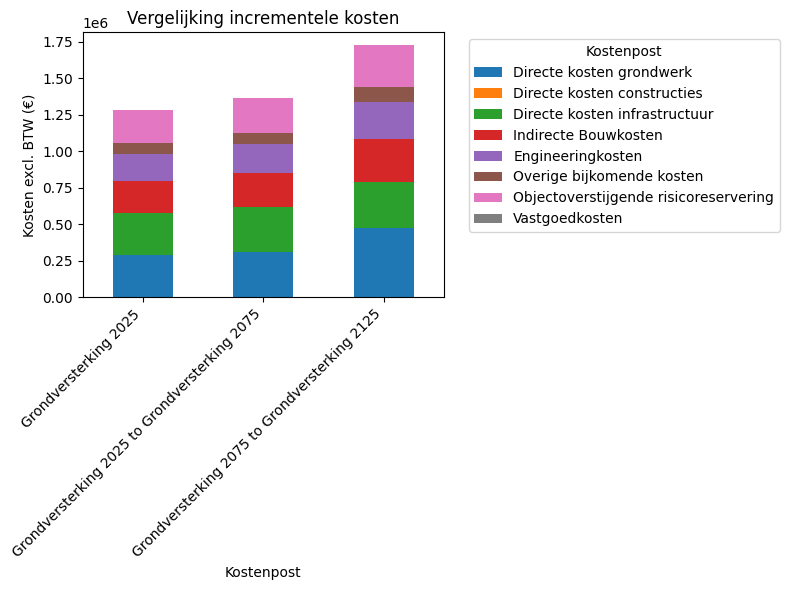

In [8]:
ax = df_all_increments.T.plot(kind="bar", figsize=(8, 6), stacked=True)

plt.title("Vergelijking incrementele kosten")
plt.ylabel("Kosten excl. BTW (€)")
plt.xlabel("Kostenpost")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Kostenpost", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
